**1. Unzipping the folder:**

In [1]:
# This unzips your data into a folder named 'dataset'
!unzip -q hardware_dataset2.zip -d dataset/
print("Dataset unzipped successfully!")

Dataset unzipped successfully!


**2. Pre-Processing:**

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    'dataset/hardware_dataset2', target_size=(224, 224), batch_size=10,
    class_mode='categorical', subset='training'
)

test_data = datagen.flow_from_directory(
    'dataset/hardware_dataset2', target_size=(224, 224), batch_size=10,
    class_mode='categorical', subset='validation'
)

Found 91 images belonging to 5 classes.
Found 20 images belonging to 5 classes.


**3. Downloading MobileNetV2 base model:**

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Load the Base Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. VERSION 2 SPECIFIC: Fine-Tuning
# Unfreeze the base model entirely first
base_model.trainable = True

# Now, loop through the first 144 layers and freeze them.
# The remaining layers (145 to 154) will stay unfrozen and learn!
for layer in base_model.layers[:144]:
    layer.trainable = False

# 3. Attach our Custom Brain
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

# 4. Compile with a MICRO Learning Rate (CRITICAL!)
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Version 2 Architecture Ready!\n")

# 5. Print the Blueprint
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Version 2 Architecture Ready!



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 897,093 (3.42 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

**4. Training and testing through MobileNetV2:**

In [4]:
print("Starting Version 2 Fine-Tuning...")
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)

Starting Version 2 Fine-Tuning...
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.2527 - loss: 1.7222 - val_accuracy: 0.4500 - val_loss: 1.4048
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.4835 - loss: 1.2394 - val_accuracy: 0.5500 - val_loss: 1.1496
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.6813 - loss: 0.9439 - val_accuracy: 0.6500 - val_loss: 0.9011
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - accuracy: 0.7802 - loss: 0.6707 - val_accuracy: 0.7500 - val_loss: 0.7195
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.7363 - loss: 0.7852 - val_accuracy: 0.8500 - val_loss: 0.5866
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.8242 - loss: 0.6700 - val_accuracy: 0.8000 - val_loss: 0.5950
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.8791 - loss: 0.4914 - val_accuracy: 0.9000 - val_loss: 0.5071
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.9011 -

**5. Evaluation Metrics:**

Found 20 images belonging to 5 classes.

Generating predictions...
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step

CLASS NAME      | PRECISION  | RECALL     | F1-SCORE   | SPECIFICITY
---------------------------------------------------------------------------
GPU             | 1.0000     | 0.7500     | 0.8571     | 1.0000    
Hard Disk       | 1.0000     | 1.0000     | 1.0000     | 1.0000    
Motherboard     | 1.0000     | 1.0000     | 1.0000     | 1.0000    
Processor       | 0.8000     | 1.0000     | 0.8889     | 0.9375    
RAM             | 1.0000     | 1.0000     | 1.0000     | 1.0000    
OVERALL METRICS |  Accuracy: 0.9500  |  Log Loss: 0.2120



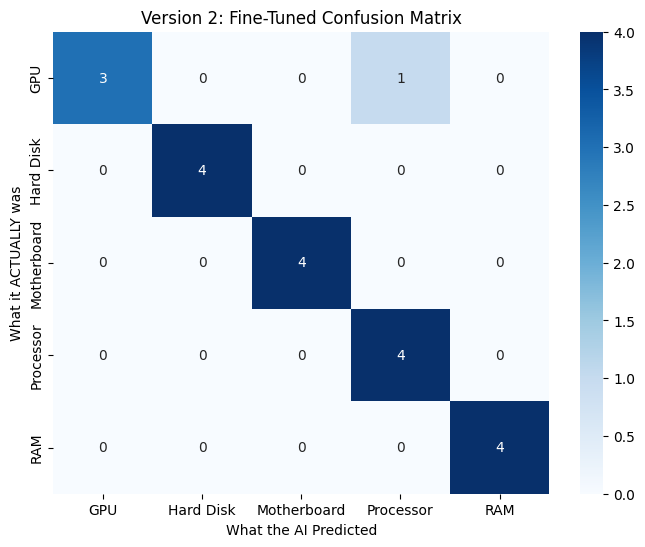

In [5]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, log_loss
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reload Test Data WITHOUT shuffling
test_data_eval = datagen.flow_from_directory(
    'dataset/hardware_dataset2', target_size=(224, 224), batch_size=10,
    class_mode='categorical', subset='validation', shuffle=False
)

# 2. Get Predictions
print("\nGenerating predictions...")
predictions = model.predict(test_data_eval)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data_eval.classes
class_names = list(test_data_eval.class_indices.keys())

# 3. Calculate Overall Log Loss
model_log_loss = log_loss(true_classes, predictions)

# 4. Extract Metrics as a Dictionary
report = classification_report(true_classes, predicted_classes, target_names=class_names, output_dict=True)
cm = confusion_matrix(true_classes, predicted_classes)
accuracy = report['accuracy']

# 5. Build and Print the Custom Formatted Table
print("\n" + "="*75)
print(f"{'CLASS NAME':<15} | {'PRECISION':<10} | {'RECALL':<10} | {'F1-SCORE':<10} | {'SPECIFICITY':<10}")
print("-" * 75)

for i, class_name in enumerate(class_names):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (tp + fp + fn)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    prec = report[class_name]['precision']
    rec = report[class_name]['recall']
    f1 = report[class_name]['f1-score']

    print(f"{class_name:<15} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f} | {specificity:<10.4f}")

print("="*75)
print(f"OVERALL METRICS |  Accuracy: {accuracy:.4f}  |  Log Loss: {model_log_loss:.4f}")
print("="*75 + "\n")

# 6. Draw the Confusion Matrix Grid
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('What the AI Predicted')
plt.ylabel('What it ACTUALLY was')
plt.title('Version 2: Fine-Tuned Confusion Matrix')
plt.show()

**6. Saving the trained model and prediction:**

Version 2 Model Saved! Don't forget to download it from the sidebar.

--- V2 LIVE DEMO: UPLOAD AN IMAGE TO TEST ---


Saving download (2).jpg to download (2).jpg

Analyzing: download (2).jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

 V2 PREDICTION : GPU
 CONFIDENCE    : 99.09%



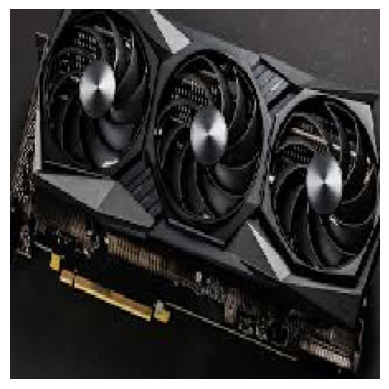

In [6]:
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt

# 1. Save the Version 2 Model
model.save('v2_hardware_model.keras')
print("Version 2 Model Saved! Don't forget to download it from the sidebar.")

# 2. Trigger the Colab Upload Button
print("\n--- V2 LIVE DEMO: UPLOAD AN IMAGE TO TEST ---")
uploaded = files.upload()

# 3. Process the uploaded image(s)
for filename in uploaded.keys():
    print(f"\nAnalyzing: {filename}...")

    img = image.load_img(filename, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction_probs = model.predict(img_array)
    winning_index = np.argmax(prediction_probs)
    confidence = np.max(prediction_probs) * 100

    print("\n" + "="*40)
    print(f" V2 PREDICTION : {class_names[winning_index]}")
    print(f" CONFIDENCE    : {confidence:.2f}%")
    print("="*40 + "\n")

    plt.imshow(img)
    plt.axis('off')
    plt.show()